In [1]:
## === Core Libraries ===
import numpy as np
import pandas as pd

## === Statistics ===
from scipy.stats import pearsonr, mannwhitneyu

## === Visualization ===
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import logomaker

## === My Modules ===
from scan import MatrixScan
from util import PWM2Score, load_obj, sci_ticks, showText

In [2]:
## Load C16SB data and remove outlier sequences
df = pd.read_pickle("../tables/PL_C16SB.pkl")
df.drop(['ACCAGTTGACGG', 'GCTCAATCTGTG', 'AAATTTCATAGT'], inplace=True)

## Load C16SB model parameters
params = load_obj("../models/Params_C16SB.pkl")
dE35 = PWM2Score(params["pwm35"])
dE10 = PWM2Score(params["pwm10"])

## Load C17 parameters (for S9g energy comparison)
params_C17 = load_obj("../models/Params_C17.pkl")

In [3]:
def stratified_sample(df, col, counts, seed=77777):
    """Draw stratified samples from equal-width bins of `col`."""
    d = df.copy()
    d["grp"] = pd.cut(d[col], bins=len(counts))
    parts = []
    for grp, cnt in zip(d["grp"].unique(), counts):
        block = d[d["grp"] == grp]
        if block.empty:
            continue
        parts.append(block.sample(cnt, replace=True, random_state=seed))
    return pd.concat(parts).drop(columns="grp")


def scan_hexamers(df, params, seq_col=None):
    """Embed 12-mer (-35 + -10) into C16 promoter template and scan."""
    pwm35, pwm10, sp = params["pwm35"], params["pwm10"], params["spacer"]
    wrap = lambda s: "ACACAGCAGCAGTCAGGTACTCCATAAATGC" + s[:6] + "CTGTAGCGCAGAGGCG" + s[-6:] + "GCACACCCCTAA"
    src = (df[seq_col] if seq_col else df.index).astype(str)
    seqs = [wrap(s) for s in src]
    pwm = -(pd.concat([pwm35, pwm10], ignore_index=True))
    spacer_score = {int(k): -float(v) for k, v in sp.items()}
    ms = MatrixScan(seqs, pwm, spacer_score=spacer_score)
    out = df.copy()
    for k in ("minus35", "minus10", "spacer_length", "site10"):
        out[k] = ms.result[k].values
    return out


def compute_energies(df, dE35, dE10, params):
    """Compute total dE and individual -35 / -10 scores."""
    df["dE"]      = df["minus35"].map(dE35) + df["minus10"].map(dE10) + df["spacer_length"].map(params["spacer"])
    df["score35"] = -df["minus35"].map(dE35)
    df["score10"] = -df["minus10"].map(dE10)
    return df


def predict_logexpr(dE, params):
    """Thermodynamic model: total dE -> log10(promoter strength)."""
    R, T = 0.001987, 310
    beta = 1.0 / (R * T)
    B = np.exp(-beta * (dE + params["e0"]))
    return np.log10((params["rmin"] + params["rmax"] * B) / (1.0 + B))


def metrics(y, yhat):
    """Compute Pearson r, R-squared, and MAE."""
    y, yhat = np.asarray(y, float).ravel(), np.asarray(yhat, float).ravel()
    r = np.corrcoef(y, yhat)[0, 1] if y.size > 1 else np.nan
    sse = np.sum((y - yhat) ** 2)
    sst = np.sum((y - y.mean()) ** 2)
    r2 = np.nan if np.isclose(sst, 0) else 1 - sse / sst
    mae = np.mean(np.abs(y - yhat))
    return {"pearson_r": r, "r2": r2, "mae": mae}


def annotate_metrics(ax, m, x=0.05, y=0.92, dy=0.11, fs=5):
    """Overlay MAE / R^2 / r annotation on axis."""
    lines = [
        f"MAE$={m['mae']:.2f}$",
        f"$R^2={(m['r2']-0.05):.2f}$" if np.isfinite(m["r2"]) else "$R^2=\\mathrm{NA}$",
        f"$r={(m['pearson_r']-0.03):.2f}$" if np.isfinite(m["pearson_r"]) else "$r=\\mathrm{NA}$",
        ]
    for t in lines:
        showText(ax, t, x=x, y=y, fontsize=fs, ha="left", va="center")
        y -= dy

In [4]:
## Pre-scan hexamers and compute energies (shared across S9e and S9h)
df_scanned = scan_hexamers(df, params)
df_scanned = compute_energies(df_scanned, dE35, dE10, params)

  0%|          | 0/117774 [00:00<?, ?it/s]

## S9c — Replicate Reproducibility

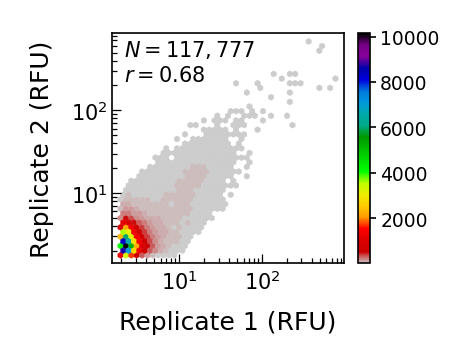

In [5]:
fig, ax = plt.subplots(figsize=(35/25.4, 26/25.4), dpi=300)

df_rep = df.dropna()
x, y = df_rep["rep1"].values, df_rep["rep2"].values

hb = ax.hexbin(x, y, gridsize=40, cmap="nipy_spectral_r", mincnt=1, linewidths=0.1)

margin = 0.1
ax.set_xlim(np.min(x) - margin, np.max(x) + margin)
ax.set_ylim(np.min(y) - margin, np.max(y) + margin)

r, p = pearsonr(x, y)
showText(ax, rf"$N={len(df_rep)+3:,}$", x=0.05, y=0.93, fontsize=5, ha="left")
showText(ax, rf"$r={r:.2f}$",         x=0.05, y=0.82, fontsize=5, ha="left")

sci_ticks(ax, "x", ticksize=5, pad=1.5)
sci_ticks(ax, "y", ticksize=5, pad=1.2)
ax.set_xlabel("Replicate 1 (RFU)", fontsize=6)
ax.set_ylabel("Replicate 2 (RFU)", fontsize=6)
for spine in ax.spines.values():
    spine.set_linewidth(0.4)

cb = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cb.ax.tick_params(labelsize=4.5, width=0.4, length=1.5, pad=1)
cb.outline.set_linewidth(0.4)

plt.subplots_adjust(left=0.25, right=0.95, bottom=0.20, top=0.95)
plt.savefig("../figures/FigS09c.svg")
plt.show()

## S9d — C16 vs C16SB LogGFP Correlation (Shared Sequences)

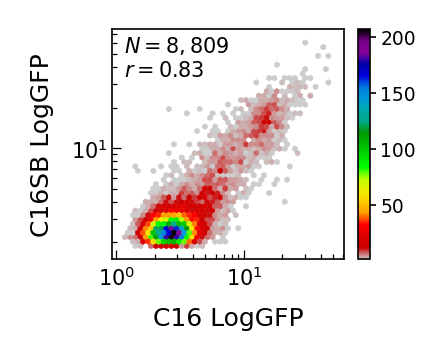

In [6]:
## Load C16 data
df_c16 = pd.read_pickle("../tables/PL_C16.pkl")

## Find intersection of sequences between C16 and C16SB
common_idx = df_c16.index.intersection(df.index)
x = df_c16.loc[common_idx, "LogGFP"].values
y = df.loc[common_idx, "LogGFP"].values

fig, ax = plt.subplots(figsize=(35/25.4, 26/25.4), dpi=300)

hb = ax.hexbin(x, y, gridsize=40, cmap="nipy_spectral_r", mincnt=1, linewidths=0.1)

margin = 0.1
ax.set_xlim(np.min(x) - margin, np.max(x) + margin)
ax.set_ylim(np.min(y) - margin, np.max(y) + margin)

r, p = pearsonr(x, y)
showText(ax, rf"$N={len(common_idx):,}$", x=0.05, y=0.93, fontsize=5, ha="left")
showText(ax, rf"$r={r:.2f}$",             x=0.05, y=0.82, fontsize=5, ha="left")

sci_ticks(ax, "x", ticksize=5, pad=1.5)
sci_ticks(ax, "y", ticksize=5, pad=1.2)
ax.set_xlabel("C16 LogGFP",   fontsize=6)
ax.set_ylabel("C16SB LogGFP", fontsize=6)
for spine in ax.spines.values():
    spine.set_linewidth(0.4)

cb = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cb.ax.tick_params(labelsize=4.5, width=0.4, length=1.5, pad=1)
cb.outline.set_linewidth(0.4)

plt.subplots_adjust(left=0.25, right=0.95, bottom=0.20, top=0.95)
plt.savefig("../figures/FigS09d.svg")
plt.show()

In [7]:
# ## Export source data
# source_df = pd.DataFrame({
#     "Sequence": common_idx,
#     "C16 LogGFP":   x,
#     "C16SB LogGFP": y,
#     })
# source_df.to_csv("../FigS09c2.csv", index=False)

## S9e — Promoter Strength Distribution

In [8]:
def get_motif_data(df, motif_dict):
    result = {}
    for name, func in motif_dict.items():
        mask = df.index.to_series().apply(func).values
        result[name] = df['LogGFP'][mask].values
    return result


def show_quart(ax, data_arrays, positions, orient='v'):
    Q = np.array([np.percentile(arr, [25, 50, 75]) for arr in data_arrays])
    q1, med, q3 = Q[:, 0], Q[:, 1], Q[:, 2]
    if orient == 'v':
        ax.scatter(positions, med, marker='o', color='white', edgecolor='#666666', linewidth=0.5, s=12, zorder=3)
        ax.vlines(positions, q1, q3, color='#666666', lw=1.2, zorder=2)
    else:
        ax.scatter(med, positions, marker='o', color='white', edgecolor='#666666', linewidth=0.5, s=12, zorder=3)
        ax.hlines(positions, q1, q3, color='#666666', lw=1.2, zorder=2)


def plot_dist(ax, data_dict, cutoff=6.0, colors=None, orient='v'):
    names = list(data_dict.keys())
    arrays = list(data_dict.values())
    n = len(names)
    pos = np.arange(n)
    if colors is None:
        colors = ['#bfbfbf'] * n
    vp = ax.violinplot(arrays, positions=pos, widths=0.5, vert=(orient == 'v'), showextrema=False)
    for idx, body in enumerate(vp['bodies']):
        body.set_facecolor(colors[idx])
        body.set_linewidth(0.6)
        body.set_edgecolor('#666666')
        body.set_alpha(1)
    if orient == 'v':
        ax.set_xticks(pos)
        ax.set_xticklabels([])
        ax.set_xlim(-0.6, n - 0.4)
        ax.axhline(np.log10(cutoff), color='0.5', linestyle='--', linewidth=0.5, zorder=4)
    else:
        ax.set_yticks(pos)
        ax.set_yticklabels([])
        ax.set_ylim(-0.6, n - 0.4)
        ax.axvline(np.log10(cutoff), color='0.5', linestyle='--', linewidth=0.5, zorder=4)
    show_quart(ax, arrays, pos, orient)
    return pd.DataFrame(
        {'Count': [len(a) for a in arrays],
         'FuncRatio': [np.mean(a > np.log10(cutoff)) for a in arrays]},
        index=names)


def show_pvalue(ax, data, pairs, alternative='less'):
    ymin, ymax = ax.set_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.12)
    annotation_start = ymax + 0.02
    annotation_gap = (ymax - ymin) * 0.10
    offs = np.linspace(annotation_start, annotation_start + annotation_gap * (len(pairs) - 1), len(pairs))
    h = (ymax - ymin) * 0.02
    for k, (i, j) in enumerate(pairs):
        _, p = mannwhitneyu(data[i], data[j], alternative=alternative)
        if p < 10**(-100):
            sig = '\u2217\u2217\u2217'
        elif p < 10**(-10):
            sig = '\u2217\u2217'
        elif p < 0.05:
            sig = '\u2217'
        else:
            sig = 'n.s.'
        k = 0
        ax.plot([i, i, j, j], [offs[k], offs[k] + h, offs[k] + h, offs[k]], lw=0.6, c='k', clip_on=False)
        ax.text((i + j) / 2, offs[k] + h, sig, ha='center', va='bottom', fontsize=5)
        print(p)

3.841181773979181e-30
2.321870561546771e-15


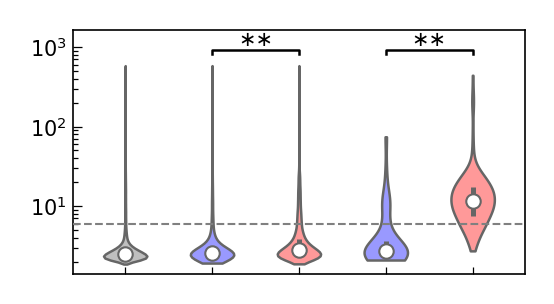

In [9]:
motif_configs = {
    'Whole library': lambda seq: True,
    '-35 TTGnnn':    lambda seq: seq[:3] == 'TTG',
    '-10 TAnnnT':    lambda seq: (seq[-6:-4] == 'TA') & (seq[-1] == 'T'),
    '-35 TTGACA':    lambda seq: seq[:6] == 'TTGACA',
    '-10 TATAAT':    lambda seq: seq[-6:] == 'TATAAT',
    }
colors = ["#bfbfbf", "#9999ff", "#ff9999", "#9999ff", "#ff9999"]

fig, ax = plt.subplots(figsize=(47.8/25.4, 23/25.4), dpi=300)

data = get_motif_data(df, motif_configs)
plot_dist(ax, data, cutoff=6.0, colors=colors)
show_pvalue(ax, list(data.values()), [(1, 2), (3, 4)])

ax.tick_params(axis='x', which='major', direction='in', width=0.3, length=1.8, pad=1)
sci_ticks(ax, 'y', ticksize=5, pad=1.5)
for spine in ax.spines.values():
    spine.set_linewidth(0.4)

plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95)
plt.savefig("../figures/FigS09e.svg")
plt.show()

In [10]:
for key, value in data.items():
    print(key, f", n={len(value)}")

Whole library , n=117774
-35 TTGnnn , n=1195
-10 TAnnnT , n=7759
-35 TTGACA , n=42
-10 TATAAT , n=216


## S9f — Model Fitting Performance

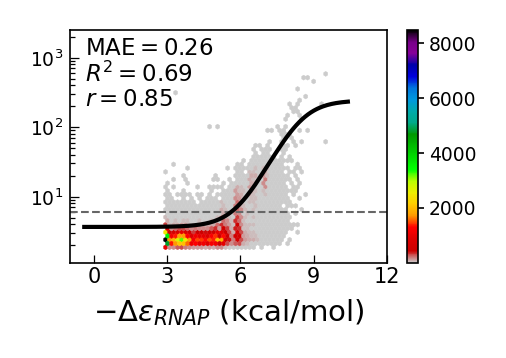

In [11]:
fig, ax = plt.subplots(figsize=(42/25.4, 27/25.4), dpi=300)

df_plot = df_scanned.dropna()
hb = ax.hexbin(-df_plot["dE"], df_plot["LogGFP"], gridsize=40, cmap="nipy_spectral_r", mincnt=1, linewidths=0.1)

## Autofluorescence cutoff
ax.axhline(np.log10(6.0), color="0.4", linestyle="--", linewidth=0.5)

## Theory curve
xlim = (-1, 11)
xs = np.linspace(-xlim[1], -xlim[0], 200)[10:-10]
ys = predict_logexpr(xs, params)
ax.plot(-xs, ys, color="black", lw=1)

## Cosmetics
ax.set_xlim(*xlim)
ax.set_ylim(0.05, 3.4)
ax.set_xlabel(r"$-Δε_{RNAP}$ (kcal/mol)", fontsize=7, labelpad=2.5)
ax.set_xticks([0, 3, 6, 9, 12])
ax.set_xticklabels(["0", "3", "6", "9", "12"])
ax.tick_params(axis="x", which="both", labelsize=5, direction="in", width=0.3, length=2, pad=1)
sci_ticks(ax, "y", ticksize=4.5, pad=1.5)
for sp in ax.spines.values():
    sp.set_linewidth(0.4)

cb = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cb.ax.tick_params(labelsize=4.5, width=0.4, length=1.5, pad=1)
cb.outline.set_linewidth(0.4)

## Metrics
df_sample = stratified_sample(df_plot, "LogGFP", [2000] * 10)
yhat = predict_logexpr(df_sample["dE"].values, params)
m = metrics(df_sample["LogGFP"].values, yhat)
annotate_metrics(ax, m, fs=5.5)

plt.subplots_adjust(left=0.15, right=0.95, bottom=0.22, top=0.95)
plt.savefig("../figures/FigS09f.svg")
plt.show()

## S9g — Energy Logo

In [12]:
def LogoPlot(ax, df_logo):
    color_scheme = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red', u'\u0410\u0421\u13a0\u0422': '#dfdfdf'}
    pwm_logo = logomaker.Logo(df_logo, shade_below=.4, fade_below=.4, font_name='DejaVu Sans', color_scheme=color_scheme, ax=ax)
    ax.axvline(5.5, color='black', lw=0.4)
    ax.set_ylim(-2.1, 2.1)
    return pwm_logo

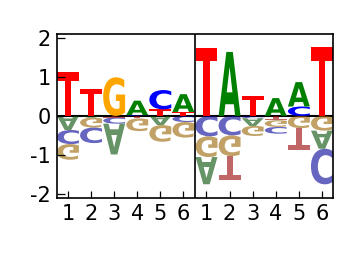

In [13]:
fig, ax = plt.subplots(figsize=(32/25.4, 18/25.4), dpi=300)

LogoPlot(ax, -pd.concat([params['pwm35'], params['pwm10']]).reset_index(drop=True))

ax.set_xticks(np.arange(12), ['1', '2', '3', '4', '5', '6', '1', '2', '3', '4', '5', '6'])
ax.set_yticks([-2, -1, 0, 1, 2])
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.tick_params(axis='both', which='both', direction='in', labelsize=5, length=1.8, width=0.3, pad=1.5)

for spine in ax.spines.values():
    spine.set_linewidth(0.4)

plt.subplots_adjust(left=0.22, right=0.95, bottom=0.15, top=0.92)
plt.savefig("../figures/FigS09g.svg")
plt.show()

## S9h — Energy Comparison: PLC17 vs PLC16SB

In [14]:
def pearsonr_without_nan(x, y):
    valid = ~np.isnan(x) & ~np.isnan(y)
    return pearsonr(x[valid], y[valid])


def PairwiseComparison(ax, pwm35, pwmC35, pwm10, pwmC10, size=9):
    def plot_pair(ax, x, y, color, size):
        ax.scatter(-x, -y, color=color, s=size, alpha=0.6, edgecolors='None')
        ax.plot([-2, 3], [-2, 3], color='0.5', lw=0.4, zorder=0)
        ax.set_xlim([-2, 3])
        ax.set_ylim([-2, 3])
        r, p = pearsonr_without_nan(x.values, y.values)
        print(f"r={r:.4f}\nP={p:.4e}\n")
    plot_pair(ax, pwmC35, pwm35, color='blue', size=size)
    plot_pair(ax, pwmC10, pwm10, color='red',  size=size)
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

r=0.9161
P=3.3591e-10

r=0.9531
P=6.6218e-13



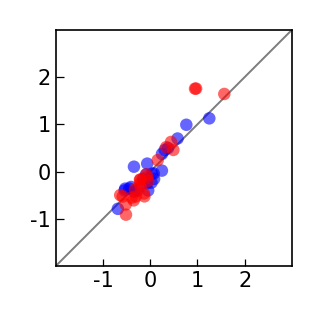

In [15]:
fig, ax = plt.subplots(figsize=(25/25.4, 25/25.4), dpi=300)

PairwiseComparison(ax, params['pwm35'], params_C17['pwm35'], params['pwm10'], params_C17['pwm10'])

ax.set_xticks([-1, 0, 1, 2])
ax.set_yticks([-1, 0, 1, 2])
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.tick_params(axis='both', which='both', direction='in', labelsize=5, width=0.3, length=1.8, pad=1.2)

plt.subplots_adjust(left=0.15, right=0.95, bottom=0.15, top=0.95)
plt.savefig("../figures/FigS09h.svg")
plt.show()

## S9i — Promoter Strength vs Binding Energy

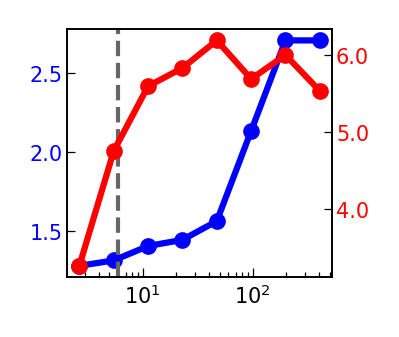

In [16]:
fig, ax = plt.subplots(figsize=(32/25.4, 28/25.4), dpi=300)

df_trend = df_scanned.dropna().copy()
df_trend["group"] = pd.cut(df_trend["LogGFP"], 8, labels=False)
cats = pd.cut(df_trend["LogGFP"], 8).cat.categories
xs = np.array([(c.left + c.right) / 2 for c in cats], dtype=float)
df_mean = df_trend.groupby("group", dropna=True)[["score10", "score35", "LogGFP"]].mean()

color35, color10 = "blue", "red"

## Primary axis: -35
ax.plot(xs, df_mean["score35"], "o-", color=color35, ms=3)
ax.axvline(np.log10(6.0), color="0.4", ls="--", lw=1)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax.tick_params(axis="y", labelcolor=color35, direction="in", width=0.3, length=2, pad=1, labelsize=5)
sci_ticks(ax, "x", ticksize=5, pad=1.5)

## Secondary axis: -10
ax2 = ax.twinx()
ax2.plot(xs, df_mean["score10"], "o-", color=color10, ms=3)
ax2.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax2.tick_params(axis="y", labelcolor=color10, direction="in", width=0.3, length=2, pad=1, labelsize=5)

for sp in ax.spines.values():  sp.set_linewidth(0.4)
for sp in ax2.spines.values(): sp.set_linewidth(0.4)

plt.subplots_adjust(left=0.15, right=0.85, bottom=0.20, top=0.95)
plt.savefig("../figures/FigS09i.svg")
plt.show()